# StarDist vs Keras — distribution comparison

Loads the CSV written by `compare-stardist-vs-keras.py` and renders one box plot per observable (nuclei count, mean / total volume, mean radius, mean / total surface area) summarising the distribution **across all timepoints**. Two boxes per panel — orange = StarDist, blue = Keras. Box = IQR, whiskers = 1.5·IQR, line = median, ▲ = mean. Individual per-timepoint points overlaid as jittered scatter so outliers stay visible.

The script writes `<input_stem>.compare.csv` into `compare_data_paths.out_dir`. Edit `CSV_PATH` below to point at it.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
CSV_PATH = Path("/mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare.csv")

# Where to save the box-plot figure. Default = next to the notebook.
# Run the notebook from ``scripts/model_prediction/`` (Jupyter's CWD =
# the notebook dir) for the default to land there; otherwise edit the
# path to an absolute location.
OUT_PNG = Path("compare_stardist_vs_keras.png")

# Optional voxel-spacing for physical-unit plots. Leave at 1.0 for
# voxel-space numbers (default — matches the script).
VOXEL_VOLUME_UM3 = 1.0   # multiply ``*_volume_vox`` by this to get µm³
VOXEL_LENGTH_UM = 1.0    # multiply ``mean_radius_vox`` by this to get µm
VOXEL_AREA_UM2 = 1.0     # multiply ``*_surface_area`` by this to get µm²

# Bar-chart colours.
COLOR_STARDIST = '#d4773a'
COLOR_KERAS = '#3a7ca5'

In [22]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"{CSV_PATH} not found — run compare-stardist-vs-keras.py first"
    )
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Sources: {df['source'].unique().tolist()}")
print(f"T-indices: {sorted(df['t_index'].unique().tolist())}")
df.head()

Loaded 30 rows from /mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare.csv
Sources: ['stardist', 'keras']
T-indices: [0, 1, 2, 3, 4, 93, 94, 95, 96, 97, 187, 188, 189, 190, 191]


,t_index,source,n_nuclei,mean_volume_vox,total_volume_vox,mean_radius_vox,mean_surface_area,total_surface_area
0,0,stardist,454,1235.123348,560746.0,6.322039,659.924384,299605.670486
1,0,keras,366,1285.986339,470671.0,6.639450,699.176312,255898.530060
2,1,stardist,469,1203.716418,564543.0,6.261071,648.464742,304129.963873
3,1,keras,377,1274.326260,480421.0,6.612595,693.607592,261490.062012
4,2,stardist,476,1211.779412,576807.0,6.287797,652.055250,310378.299199


In [23]:
# Pivot to wide form so each metric is a pair of columns (one per source).
metric_cols = [c for c in df.columns if c not in ('t_index', 'source')]
wide = df.pivot(index='t_index', columns='source', values=metric_cols).sort_index()
wide.columns = [f'{m}__{s}' for m, s in wide.columns]
wide.reset_index(inplace=True)
wide

,t_index,n_nuclei__keras,n_nuclei__stardist,mean_volume_vox__keras,mean_volume_vox__stardist,total_volume_vox__keras,total_volume_vox__stardist,mean_radius_vox__keras,mean_radius_vox__stardist,mean_surface_area__keras,mean_surface_area__stardist,total_surface_area__keras,total_surface_area__stardist
0,0,366.0,454.0,1285.986339,1235.123348,470671.0,560746.0,6.639450,6.322039,699.176312,659.924384,2.558985e+05,2.996057e+05
1,1,377.0,469.0,1274.326260,1203.716418,480421.0,564543.0,6.612595,6.261071,693.607592,648.464742,2.614901e+05,3.041300e+05
2,2,383.0,476.0,1298.412533,1211.779412,497292.0,576807.0,6.648163,6.287797,700.481618,652.055250,2.682845e+05,3.103783e+05
3,3,384.0,471.0,1318.661458,1190.673036,506366.0,560807.0,6.694118,6.296836,707.685703,647.926794,2.717513e+05,3.051735e+05
4,4,390.0,471.0,1313.015385,1213.322718,512076.0,571475.0,6.688552,6.320527,707.415453,654.806663,2.758920e+05,3.084139e+05
5,93,1325.0,1443.0,1246.796981,899.425502,1652006.0,1297871.0,6.565246,5.805111,703.077921,561.742625,9.315782e+05,8.105946e+05
6,94,1336.0,1462.0,1243.196108,887.854993,1660910.0,1298044.0,6.559042,5.779929,702.216128,557.884904,9.381607e+05,8.156277e+05
7,95,1360.0,1479.0,1231.869118,887.979716,1675342.0,1313322.0,6.534699,5.783924,697.278258,557.873218,9.482984e+05,8.250945e+05
8,96,1371.0,1527.0,1236.270605,870.163065,1694927.0,1328739.0,6.546025,5.721333,699.867567,548.872019,9.595184e+05,8.381276e+05
9,97,1394.0,1527.0,1235.309182,879.142109,1722021.0,1342450.0,6.540588,5.752165,699.725255,553.559147,9.754170e+05,8.452848e+05


In [24]:
# Per-metric mean across timepoints — a single-number sanity table.
rows = []
for m in metric_cols:
    sd = wide.get(f'{m}__stardist')
    kr = wide.get(f'{m}__keras')
    if sd is None or kr is None:
        continue
    rows.append({
        'metric': m,
        'stardist_mean': float(sd.mean()),
        'keras_mean': float(kr.mean()),
        'ratio_sd_over_keras': float(sd.mean() / kr.mean()) if kr.mean() else float('nan'),
    })
pd.DataFrame(rows)

,metric,stardist_mean,keras_mean,ratio_sd_over_keras
0,n_nuclei,1.704400e+03,1.476400e+03,1.154430
1,mean_volume_vox,9.379112e+02,1.210204e+03,0.775002
2,total_volume_vox,1.383190e+06,1.706339e+06,0.810618
3,mean_radius_vox,5.814061e+00,6.496257e+00,0.894986
4,mean_surface_area,5.711412e+02,6.929984e+02,0.824159
5,total_surface_area,9.087690e+05,1.013145e+06,0.896978


Saved /mnt/disk/python_workspace/KapoorLabs-VollSeg/scripts/model_prediction/compare_stardist_vs_keras.png


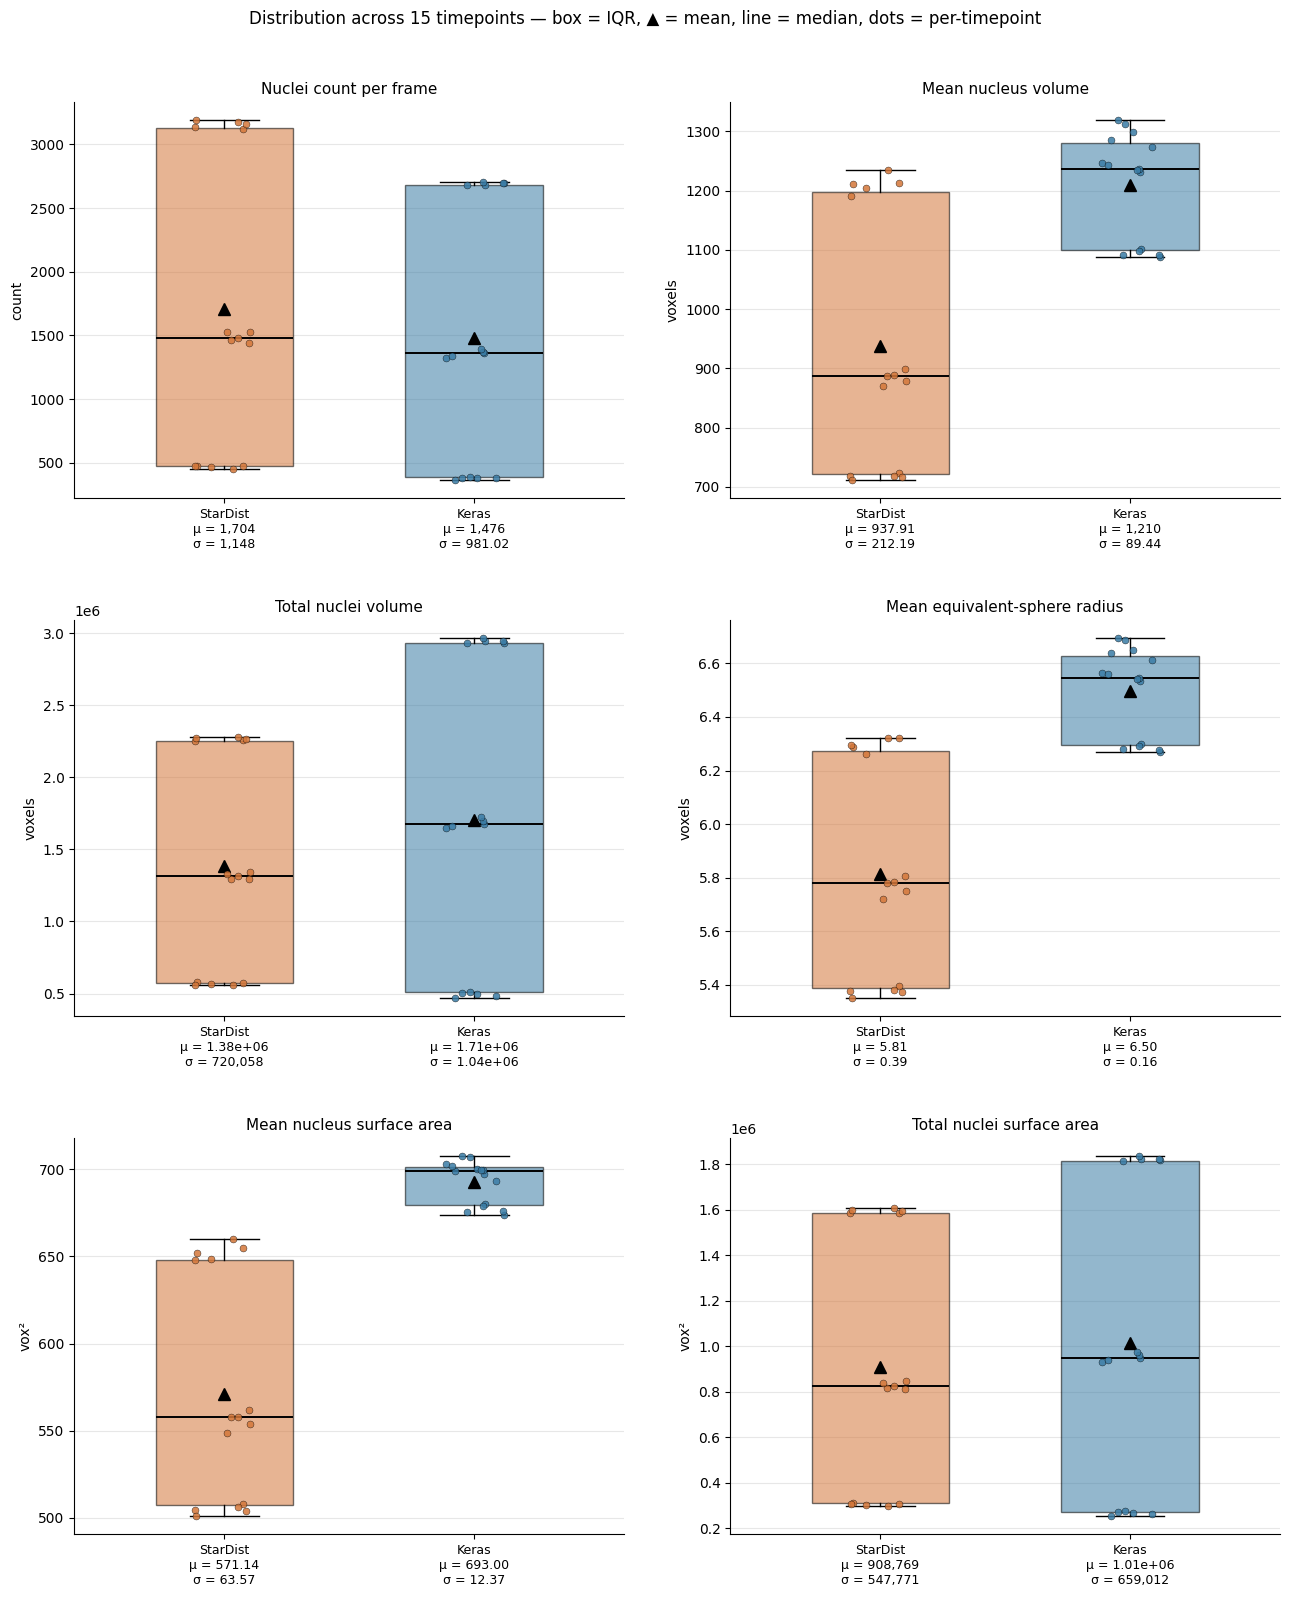

In [25]:
# Box plots per metric — distributions across all timepoints, two
# boxes per panel (StarDist vs Keras). Whisker convention = 1.5·IQR;
# triangle = sample mean; horizontal line = median; jittered scatter
# overlay = individual timepoints so outlier frames stay visible.
# Mean ± std is baked into each x-tick label so the axes stay clean.

plots = [
    ("n_nuclei",           "count",  1.0,              "Nuclei count per frame"),
    ("mean_volume_vox",    "voxels", VOXEL_VOLUME_UM3, "Mean nucleus volume"),
    ("total_volume_vox",   "voxels", VOXEL_VOLUME_UM3, "Total nuclei volume"),
    ("mean_radius_vox",    "voxels", VOXEL_LENGTH_UM,  "Mean equivalent-sphere radius"),
    ("mean_surface_area",  "vox²",   VOXEL_AREA_UM2,   "Mean nucleus surface area"),
    ("total_surface_area", "vox²",   VOXEL_AREA_UM2,   "Total nuclei surface area"),
]


def _fmt(v: float) -> str:
    """Compact axis-label formatter — scientific only when needed."""
    av = abs(v)
    if av >= 1e6 or (av < 1e-2 and av != 0):
        return f"{v:.2e}"
    if av >= 1e3:
        return f"{v:,.0f}"
    return f"{v:.2f}"


def _box_pair(ax, sd_vals, kr_vals, ylabel, title):
    """Two-box panel: StarDist (orange) vs Keras (blue).

    Box: Q1–Q3 + median line; whiskers: 1.5·IQR; ▲: mean;
    overlay: jittered scatter of every timepoint. Mean ± std is
    rendered into the x-tick label of each box so the annotation
    never collides with the bottom of the axes.
    """
    data = [sd_vals, kr_vals]
    colors = [COLOR_STARDIST, COLOR_KERAS]
    positions = [1, 2]
    labels = []
    for name, vals in zip(["StarDist", "Keras"], data):
        if len(vals) == 0:
            labels.append(f"{name}\n(no data)")
        else:
            labels.append(
                f"{name}\nμ = {_fmt(float(np.mean(vals)))}\n"
                f"σ = {_fmt(float(np.std(vals, ddof=1)))}"
            )

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        showmeans=True,
        meanprops=dict(marker="^", markerfacecolor="black",
                       markeredgecolor="black", markersize=8),
        medianprops=dict(color="black", linewidth=1.4),
        boxprops=dict(linewidth=1.0),
        whiskerprops=dict(linewidth=1.0, color="black"),
        capprops=dict(linewidth=1.0, color="black"),
        flierprops=dict(marker="o", markersize=4, alpha=0.5),
        patch_artist=True,
    )
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.55)
        patch.set_edgecolor("black")

    # Jittered scatter so every per-timepoint sample is visible.
    rng = np.random.default_rng(0)
    for pos, vals, c in zip(positions, data, colors):
        if len(vals) == 0:
            continue
        x = pos + rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(x, vals, color=c, edgecolor="black",
                   linewidth=0.3, s=25, alpha=0.85, zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.tick_params(axis="x", pad=4)
    ax.set_xlim(0.4, 2.6)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig, axes = plt.subplots(3, 2, figsize=(13, 16))
axes = axes.flatten()
for ax, (metric, unit, scale, title) in zip(axes, plots):
    sd_col = f"{metric}__stardist"
    kr_col = f"{metric}__keras"
    if sd_col not in wide.columns or kr_col not in wide.columns:
        ax.set_axis_off()
        ax.set_title(f"{metric} — missing")
        continue
    sd_vals = (wide[sd_col].dropna() * scale).to_numpy()
    kr_vals = (wide[kr_col].dropna() * scale).to_numpy()
    _box_pair(ax, sd_vals, kr_vals, ylabel=unit, title=title)

fig.suptitle(
    f"Distribution across {len(wide)} timepoints — "
    f"box = IQR, ▲ = mean, line = median, dots = per-timepoint",
    fontsize=12, y=0.995,
)
fig.tight_layout(rect=(0, 0, 1, 0.98), h_pad=3.5, w_pad=3.0)

# Save next to the notebook (or wherever OUT_PNG points). dpi=200
# keeps the figure crisp for the README without bloating the file.
OUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT_PNG, dpi=200, bbox_inches="tight", facecolor="white")
print(f"Saved {OUT_PNG.resolve()}")

plt.show()